<a href="https://colab.research.google.com/github/CIA-Oceanix/FM_Tutorial_2026/blob/main/flow_matching_CIFAR_10_solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# Assuming that we are on a CUDA machine, this should print a CUDA device:

print(device)


cpu


In [ ]:

# fetch data, show a few images

transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

batch_size = 512
nb_img_display = 5

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=4, pin_memory=True, prefetch_factor=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=4, pin_memory=True, prefetch_factor=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

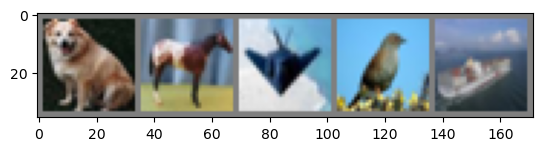

dog   horse plane bird  ship 


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image


def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images[:nb_img_display,:,:]))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(nb_img_display)))

In [ ]:
import math
import torch
from torch import nn
from torch.nn import init
from torch.nn import functional as F


class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)


class TimeEmbedding(nn.Module):
    """Continuous sinusoidal time embedding + small MLP.

    Constructor signature is (T, d_model, dim) to remain compatible with callers.
    - T is used only as a scale (so T=1000 behaves like the original discrete setting)
    - d_model is the dimension of the sinusoidal embedding
    - dim is the output embedding size (temb) consumed by ResBlocks
    """

    def __init__(self, T: int, d_model: int, dim: int):
        super().__init__()
        assert d_model % 2 == 0, 'd_model must be even for sin/cos pairs'
        self.d_model = d_model
        self.out_dim = dim
        # scale for mapping t in [0,1] to [0, T-1]
        self.T = float(max(1, T - 1))

        self.mlp = nn.Sequential(
            nn.Linear(d_model, dim),
            Swish(),
            nn.Linear(dim, dim),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.mlp.modules():
            if isinstance(m, nn.Linear):
                init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    init.zeros_(m.bias)

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        """
        t: shape (B,) or (B,1). Either float in [0,1] (continuous) or integer indices (LongTensor).
        returns: (B, out_dim)
        """
        if t.dim() == 0:
            t = t.unsqueeze(0)
        if t.dim() == 2 and t.size(1) == 1:
            t = t.squeeze(1)

        if not t.is_floating_point():
            t = t.float()
            t_scaled = t
        else:
            t_scaled = t * self.T

        half = self.d_model // 2
        freq_exponents = torch.arange(half, dtype=torch.float32, device=t.device)
        inv_freq = torch.exp(-math.log(10000.0) * freq_exponents / (half - 1))
        args = t_scaled.unsqueeze(-1) * inv_freq.unsqueeze(0)
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

        # in case of numeric mismatch pad (shouldn't be necessary because d_model even)
        if emb.shape[-1] != self.d_model:
            pad = self.d_model - emb.shape[-1]
            emb = torch.cat([emb, torch.zeros(emb.shape[0], pad, device=emb.device)], dim=-1)

        return self.mlp(emb)


class DownSample(nn.Module):
    def __init__(self, in_ch: int):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, in_ch, kernel_size=3, stride=2, padding=1)
        init.xavier_uniform_(self.conv.weight)
        init.zeros_(self.conv.bias)

    def forward(self, x: torch.Tensor, temb: torch.Tensor) -> torch.Tensor:
        return self.conv(x)


class UpSample(nn.Module):
    def __init__(self, in_ch: int):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, in_ch, kernel_size=3, stride=1, padding=1)
        init.xavier_uniform_(self.conv.weight)
        init.zeros_(self.conv.bias)

    def forward(self, x: torch.Tensor, temb: torch.Tensor) -> torch.Tensor:
        x = F.interpolate(x, scale_factor=2, mode='nearest')
        return self.conv(x)


class AttnBlock(nn.Module):
    def __init__(self, in_ch: int):
        super().__init__()
        # note: original code used GroupNorm(32, in_ch); keep it but beware if in_ch < 32
        self.norm = nn.GroupNorm(32, in_ch)
        self.q = nn.Conv2d(in_ch, in_ch, 1)
        self.k = nn.Conv2d(in_ch, in_ch, 1)
        self.v = nn.Conv2d(in_ch, in_ch, 1)
        self.proj = nn.Conv2d(in_ch, in_ch, 1)
        for m in [self.q, self.k, self.v, self.proj]:
            init.xavier_uniform_(m.weight)
            init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, C, H, W = x.shape
        h = self.norm(x)
        q = self.q(h).reshape(B, C, H * W).permute(0, 2, 1)  # (B, HW, C)
        k = self.k(h).reshape(B, C, H * W)                   # (B, C, HW)
        attn = torch.bmm(q, k) * (C ** -0.5)
        attn = F.softmax(attn, dim=-1)
        v = self.v(h).reshape(B, C, H * W).permute(0, 2, 1)  # (B, HW, C)
        out = torch.bmm(attn, v).permute(0, 2, 1).reshape(B, C, H, W)
        out = self.proj(out)
        return x + out


class ResBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, tdim: int, dropout: float, attn: bool = False):
        super().__init__()
        self.in_ch = in_ch
        self.out_ch = out_ch
        self.block1 = nn.Sequential(
            nn.GroupNorm(32, in_ch),
            Swish(),
            nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=1, padding=1),
        )
        self.temb_proj = nn.Sequential(
            Swish(),
            nn.Linear(tdim, out_ch),
        )
        self.block2 = nn.Sequential(
            nn.GroupNorm(32, out_ch),
            Swish(),
            nn.Dropout(dropout),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, stride=1, padding=1),
        )
        if in_ch != out_ch:
            self.shortcut = nn.Conv2d(in_ch, out_ch, kernel_size=1, stride=1, padding=0)
        else:
            self.shortcut = nn.Identity()

        self.attn = AttnBlock(out_ch) if attn else nn.Identity()

        # init
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                init.xavier_uniform_(m.weight)
                if getattr(m, 'bias', None) is not None:
                    init.zeros_(m.bias)
        # small gain for final conv to stabilize initial outputs
        init.xavier_uniform_(self.block2[-1].weight, gain=1e-5)

    def forward(self, x: torch.Tensor, temb: torch.Tensor) -> torch.Tensor:
        h = self.block1(x)
        # temb: (B, tdim) -> project and add
        temb_proj = self.temb_proj(temb).unsqueeze(-1).unsqueeze(-1)
        h = h + temb_proj
        h = self.block2(h)
        h = h + self.shortcut(x)
        h = self.attn(h)
        return h


class UNet(nn.Module):
    def __init__(self, T: int, ch: int, ch_mult, attn, num_res_blocks: int, dropout: float):
        super().__init__()
        assert all([i < len(ch_mult) for i in attn]), 'attn index out of bound'
        tdim = ch * 4

        # time embedding: d_model choose ch (can be tuned), output tdim
        self.time_embedding = TimeEmbedding(T, ch, tdim)

        # head conv
        self.head = nn.Conv2d(3, ch, kernel_size=3, stride=1, padding=1)
        init.xavier_uniform_(self.head.weight)
        init.zeros_(self.head.bias)

        # build down path and record channels for skip-connections
        self.downblocks = nn.ModuleList()
        chs = [ch]  # channel sizes that will be pushed in the same order as forward hs
        now_ch = ch
        for i, mult in enumerate(ch_mult):
            out_ch = ch * mult
            for _ in range(num_res_blocks):
                self.downblocks.append(
                    ResBlock(now_ch, out_ch, tdim, dropout, attn=(i in attn))
                )
                now_ch = out_ch
                chs.append(now_ch)
            if i != len(ch_mult) - 1:
                # downsample
                self.downblocks.append(DownSample(now_ch))
                chs.append(now_ch)

        # middle blocks
        self.middleblocks = nn.ModuleList([
            ResBlock(now_ch, now_ch, tdim, dropout, attn=True),
            ResBlock(now_ch, now_ch, tdim, dropout, attn=False),
        ])

        # build up path: pop chs in reverse order to compute input channels for concatenation
        self.upblocks = nn.ModuleList()
        for i, mult in reversed(list(enumerate(ch_mult))):
            out_ch = ch * mult
            # create (num_res_blocks + 1) ResBlocks per level to mirror down path
            for _ in range(num_res_blocks + 1):
                skip_ch = chs.pop()
                in_ch = now_ch + skip_ch
                self.upblocks.append(
                    ResBlock(in_ch, out_ch, tdim, dropout, attn=(i in attn))
                )
                now_ch = out_ch
            if i != 0:
                self.upblocks.append(UpSample(now_ch))

        assert len(chs) == 0, 'Channel stack should be empty after building up path'

        # tail
        self.tail = nn.Sequential(
            nn.GroupNorm(32, now_ch),
            Swish(),
            nn.Conv2d(now_ch, 3, kernel_size=3, stride=1, padding=1),
        )
        init.xavier_uniform_(self.tail[-1].weight, gain=1e-5)
        init.zeros_(self.tail[-1].bias)

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        # t: float in [0,1] or Long indices 0..T-1
        temb = self.time_embedding(t)

        # down path
        h = self.head(x)
        hs = [h]
        for layer in self.downblocks:
            h = layer(h, temb)
            # push every intermediate feature (after both ResBlock and DownSample)
            hs.append(h)

        # middle
        for layer in self.middleblocks:
            h = layer(h, temb)

        # up path
        for layer in self.upblocks:
            if isinstance(layer, ResBlock):
                skip = hs.pop()
                # spatial sizes must match; this invariant holds if down and up were built symmetrically
                h = torch.cat([h, skip], dim=1)
                h = layer(h, temb)
            else:
                h = layer(h, temb)

        h = self.tail(h)
        # all skip features should have been consumed
        assert len(hs) == 0
        return h



In [ ]:
# vector_field = UNet().to(device)
if __name__ == '__main__':
    # quick local test
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    batch_size = 8
    vector_field = UNet(
        T=1000,
        ch=32,
        ch_mult=[1, 2, 2, 2],
        attn=[1],
        num_res_blocks=1,
        dropout=0.1,
    ).to(device)


pytorch_total_params = sum(p.numel() for p in vector_field.parameters() if p.requires_grad)

print(pytorch_total_params)

1525411


In [ ]:
# Define the loss function

def loss_fn(model, x,sigma):
    """The loss function for training flow matching generative models.

    Args:
    model: A PyTorch model instance that represents a
      time-dependent U-NET model.
    x: A mini-batch of training data.
    """
    t = torch.rand(x.shape[0], device=x.device) # generate batch of random t uniformly between 0 and 1
    t_broadcast = t.view(-1, 1, 1, 1)
    y = torch.randn_like(x) # generate batch of gaussian latents
    interp = (1-t_broadcast)*y + t_broadcast*x # linear interpolations defining the conditional paths
    interp_sto = sigma*torch.randn_like(x) + interp
    vt = model(interp_sto, t)
    loss = torch.mean(torch.sum((vt - (x-y))**2,dim = (1,2,3))) # regression loss
    return loss

In [ ]:
#Training

import torch
import functools
from torch.optim import Adam, AdamW
from torch.utils.data import DataLoader
from torch.optim import lr_scheduler
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10
import tqdm.notebook


epochs = 200
sigma = 1e-3

for p in vector_field.parameters():
    p.requires_grad = True

optimizer = torch.optim.AdamW(vector_field.parameters(), lr=1e-4, weight_decay=0)
# OneCycle: set max_lr and total_steps
steps_per_epoch = len(trainloader)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=1e-3,
                                                total_steps=epochs * steps_per_epoch,
                                                pct_start=0.3, anneal_strategy='cos')



# optimizer = Adam(vector_field.parameters(), lr=lr)
tqdm_epoch = tqdm.notebook.trange(epochs)
losses = torch.zeros(epochs)

for epoch in tqdm_epoch:
  avg_loss = 0.
  num_items = 0
  for x, y in trainloader:
    x = x.to(device,non_blocking=True)
    loss = loss_fn(vector_field, x, sigma)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    # optimizer_diagnostics(vector_field, optimizer)
    # with torch.no_grad():
    #     some_param = next(vector_field.parameters())
    #     print(some_param.norm().item())

    scheduler.step()
    avg_loss += loss.item() * x.shape[0]
    num_items += x.shape[0]
  # Print the averaged training loss so far.
  losses[epoch] = avg_loss/num_items
  tqdm_epoch.set_description('Average Loss: {:5f}'.format(avg_loss / num_items))
  # Update the checkpoint after each epoch of training.
  torch.save(vector_field.state_dict(), 'ckpt.pth')

  0%|          | 0/200 [00:00<?, ?it/s]

KeyboardInterrupt: 

tensor(570.7402)


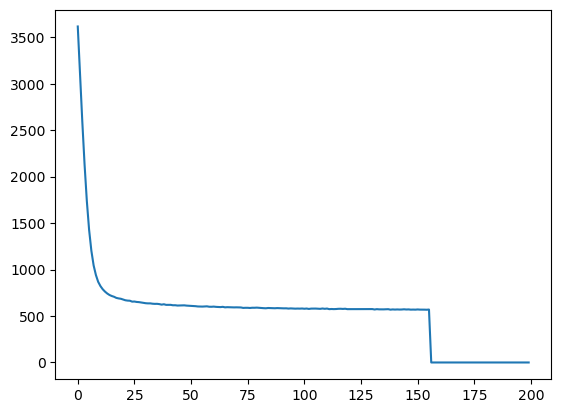

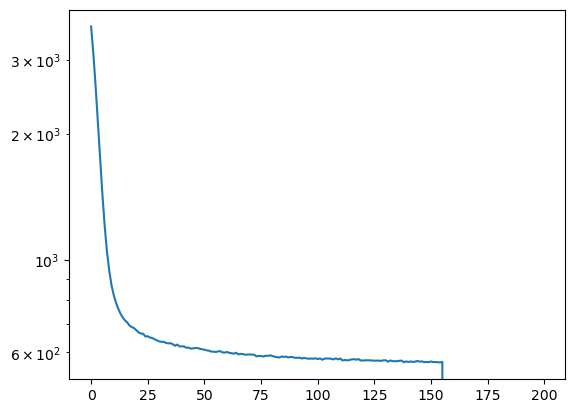

In [ ]:
print(losses[150])
plt.plot(losses)
plt.figure()
plt.semilogy(losses)

In [ ]:
# generate samples (call an ODE solver from a latent sample with the vector field)

# from torchdiffeq import odeint

n_steps = 10000
batch_size_test = 64


with torch.no_grad():
    t = torch.linspace(0,1,steps = n_steps).to(device)
    h = t[1]-t[0]
    z = torch.randn(batch_size_test,3,32,32) # generate gaussian latent
    samples = torch.clone(z).to(device)
    for i in range(n_steps):
        if np.mod(i,1000) ==0:
            print(i)
        samples = samples + h.to(device) * vector_field(samples, t[i].unsqueeze(0))

print(samples.size())

0
1000
2000
3000
4000
5000
6000
7000
8000
9000
torch.Size([64, 3, 32, 32])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.1577087..1.1698768].


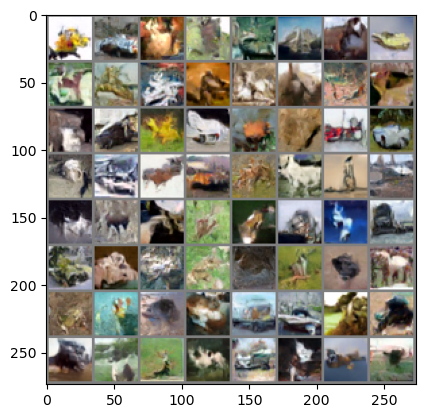

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.04708129..1.135854].


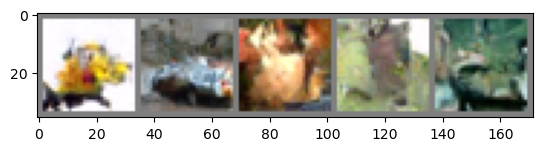

In [ ]:

# imshow(torchvision.utils.make_grid(normalize_batch_minmax(samples).cpu().detach()))

imshow(torchvision.utils.make_grid(samples.cpu().detach()))

# show images
imshow(torchvision.utils.make_grid(samples.cpu().detach()[:nb_img_display,:,:]))

